# 01 – Data Understanding and Dataset Construction

## Research Question

Can the physical properties of a star be used to predict whether its orbiting planet is a gas giant?

This project investigates whether measurable properties of a host star—including effective temperature, radius, and metallicity—contain enough information to distinguish gas giant exoplanets from other planetary types using supervised machine learning.

## Scientific Motivation

Understanding the relationship between stars and their planets is a fundamental question in exoplanet science. Stellar properties influence the conditions under which planetary systems form and evolve, making them valuable predictors of planetary characteristics.

Rather than focusing solely on predictive accuracy, this project also explores the scientific relationships between stellar environments and gas giant occurrence while acknowledging the observational limitations of real astronomical survey data.

## Dataset

The dataset used in this project was obtained from the NASA Exoplanet Archive and contains confirmed exoplanets discovered using multiple observational techniques, including the transit and radial velocity methods. The catalog includes measurements describing planetary orbits, planetary physical properties, stellar characteristics, and system-level information.

This notebook focuses exclusively on understanding the raw dataset before any preprocessing, feature engineering, or machine learning is performed.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Data Provenance

The dataset was obtained from the NASA Exoplanet Archive and saved locally as
`exoplanets_raw.csv`.

The raw dataset is preserved without modification in:

`data/raw/exoplanets_raw.csv`

All subsequent preprocessing steps are performed on copies of this raw dataset.

In [3]:
from pathlib import Path

DATA_PATH = Path("../data/raw/exoplanets_raw.csv")

df = pd.read_csv(DATA_PATH, comment="#")

print(f"Dataset loaded successfully with {df.shape[0]:,} rows and {df.shape[1]} columns.")
print(f"Dataset path: {DATA_PATH}")

Dataset loaded successfully with 39,954 rows and 50 columns.
Dataset path: ..\data\raw\exoplanets_raw.csv


In [4]:
dataset_summary = pd.DataFrame({
    "Metric": [
        "Number of rows",
        "Number of columns",
        "Numeric columns",
        "Categorical columns",
        "Duplicate planet names"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df.select_dtypes(include="number").shape[1],
        df.select_dtypes(exclude="number").shape[1],
        df["pl_name"].duplicated().sum()
    ]
})

dataset_summary

,Metric,Value
0,Number of rows,39954
1,Number of columns,50
2,Numeric columns,47
3,Categorical columns,3
4,Duplicate planet names,33638


In [5]:
columns = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

columns

,Column,Data Type
0,pl_name,str
1,discoverymethod,str
2,pl_orbper,float64
3,pl_orbpererr1,float64
4,pl_orbpererr2,float64
5,pl_orbperlim,float64
6,pl_rade,float64
7,pl_radeerr1,float64
8,pl_radeerr2,float64
9,pl_radelim,float64


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39954 entries, 0 to 39953
Data columns (total 50 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          39954 non-null  str    
 1   discoverymethod  39954 non-null  str    
 2   pl_orbper        36595 non-null  float64
 3   pl_orbpererr1    34884 non-null  float64
 4   pl_orbpererr2    34883 non-null  float64
 5   pl_orbperlim     36595 non-null  float64
 6   pl_rade          27540 non-null  float64
 7   pl_radeerr1      26795 non-null  float64
 8   pl_radeerr2      26795 non-null  float64
 9   pl_radelim       30286 non-null  float64
 10  pl_msinie        2731 non-null   float64
 11  pl_msinieerr1    2460 non-null   float64
 12  pl_msinieerr2    2460 non-null   float64
 13  pl_msinielim     2731 non-null   float64
 14  pl_orbeccen      19019 non-null  float64
 15  pl_orbeccenerr1  3945 non-null   float64
 16  pl_orbeccenerr2  3944 non-null   float64
 17  pl_orbeccenlim   21763 

In [7]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing.sort_values(
    "Missing (%)",
    ascending=False
)

missing.head(20)

,Missing Values,Missing (%)
pl_msinieerr1,37494,93.84
pl_msinieerr2,37494,93.84
pl_eqterr2,37246,93.22
pl_eqterr1,37246,93.22
pl_msinielim,37223,93.16
pl_msinie,37223,93.16
st_spectype,36851,92.23
pl_orbeccenerr2,36010,90.13
pl_orbeccenerr1,36009,90.13
st_lumerr2,35109,87.87


In [8]:
duplicate_planets = df["pl_name"].duplicated().sum()

print(f"Duplicate planet-name rows: {duplicate_planets:,}")
print(
    f"Percentage of rows sharing a previously observed planet name: "
    f"{duplicate_planets / len(df) * 100:.2f}%"
)   

duplicate_counts = (
    df["pl_name"]
    .value_counts()
)

duplicate_counts.head(10)

Duplicate planet-name rows: 33,638
Percentage of rows sharing a previously observed planet name: 84.19%


pl_name
TrES-2 b       34
Kepler-10 b    25
GJ 436 b       24
HAT-P-7 b      24
HAT-P-11 b     23
HD 209458 b    23
WASP-4 b       22
55 Cnc e       21
HD 189733 b    21
Kepler-10 c    21
Name: count, dtype: int64

In [9]:
duplicate_frequency = (
    duplicate_counts
    .value_counts()
    .sort_index()
    .rename_axis("Number of Records per Planet")
    .reset_index(name="Number of Planets")
)

duplicate_frequency

,Number of Records per Planet,Number of Planets
0,1,929
1,2,1071
2,3,537
3,4,335
4,5,216
5,6,199
6,7,255
7,8,378
8,9,465
9,10,633


In [10]:
df.describe()

,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_rade,pl_radeerr1,pl_radeerr2,pl_radelim,pl_msinie,pl_msinieerr1,pl_msinieerr2,pl_msinielim,pl_orbeccen,pl_orbeccenerr1,pl_orbeccenerr2,pl_orbeccenlim,pl_eqt,pl_eqterr1,pl_eqterr2,pl_eqtlim,st_teff,st_tefferr1,st_tefferr2,st_tefflim,st_rad,st_raderr1,st_raderr2,st_radlim,st_met,st_meterr1,st_meterr2,st_metlim,st_lum,st_lumerr1,st_lumerr2,st_lumlim,st_logg,st_loggerr1,st_loggerr2,st_logglim,st_age,st_ageerr1,st_ageerr2,st_agelim,sy_dist,sy_disterr1,sy_disterr2
count,3.659500e+04,3.488400e+04,3.488300e+04,36595.000000,27540.000000,26795.000000,26795.000000,30286.000000,2731.000000,2460.000000,2460.000000,2731.000000,19019.000000,3945.000000,3944.000000,21763.000000,17535.000000,2708.000000,2708.000000,20279.000000,36351.000000,35395.000000,35135.000000,36351.000000,36542.000000,30834.000000,30681.000000,36542.000000,25026.000000,24351.000000,24351.000000,27338.000000,9818.000000,4900.000000,4845.000000,9818.000000,30979.000000,25521.000000,25520.000000,30979.000000,9834.000000,9375.000000,9375.000000,21214.000000,39100.000000,38237.000000,38237.000000
mean,1.196132e+04,1.382946e+04,-3.259654e+03,-0.000246,5.446621,1.936948,-0.762182,-0.000132,754.363525,95.260145,-86.730985,0.001831,0.048064,0.061649,-0.050104,0.030005,881.214693,32.645159,-31.840694,0.000148,5455.549110,115.601809,-117.488462,0.000028,1.150763,0.201055,-0.125947,0.000055,-0.021687,0.141284,-0.152267,-0.000183,-0.155455,0.037596,-0.041046,0.000204,4.411590,0.099101,-0.152428,-0.000194,4.617140,2.394776,-1.958636,-0.007354,721.138011,36.958126,-38.638563
std,2.102652e+06,2.516611e+06,5.366524e+05,0.020245,71.212750,74.735067,18.890319,0.014075,1212.893344,586.842737,561.822040,0.057388,0.127527,0.066200,0.051950,0.183579,429.507530,49.668790,49.506257,0.012162,996.227806,84.735135,86.420840,0.005245,1.779156,0.862715,0.600472,0.007398,0.227038,0.097299,0.104739,0.018144,0.727570,0.039631,0.056010,0.014272,0.301762,0.110765,0.138738,0.016069,3.480304,1.809221,1.338874,0.102496,834.733135,158.350847,184.599385
min,9.070629e-02,0.000000e+00,-1.000000e+08,-1.000000,0.270000,0.000000,-1916.293000,-1.000000,0.015000,0.000000,-24965.546500,-1.000000,-0.011000,0.000000,-0.703000,-1.000000,34.000000,0.000000,-1217.000000,0.000000,415.000000,0.000000,-6064.900000,0.000000,0.012100,0.000000,-73.630000,0.000000,-2.500000,0.000000,-1.000000,-1.000000,-4.660000,0.000170,-1.431360,0.000000,0.100000,0.000000,-3.510000,-1.000000,0.000000,0.000000,-18.000000,-1.000000,1.301190,0.000340,-2900.000000
25%,4.362737e+00,8.009250e-06,-2.006000e-04,0.000000,1.560000,0.158000,-0.460000,0.000000,21.606166,2.692440,-63.565681,0.000000,0.000000,0.016000,-0.070000,0.000000,568.000000,12.000000,-36.000000,0.000000,5090.000000,76.000000,-146.000000,0.000000,0.785000,0.039000,-0.110000,0.000000,-0.148900,0.060000,-0.260000,0.000000,-0.467370,0.015287,-0.049770,0.000000,4.310000,0.033000,-0.260000,0.000000,2.100000,0.940000,-2.900000,0.000000,268.685000,1.909500,-20.190000
50%,1.030066e+01,3.824000e-05,-3.829000e-05,0.000000,2.308000,0.362309,-0.220000,0.000000,324.186600,19.069704,-19.069704,0.000000,0.000000,0.040000,-0.035000,0.000000,798.000000,21.000000,-20.000000,0.000000,5609.000000,113.000000,-117.000000,0.000000,0.950000,0.078000,-0.062000,0.000000,-0.000600,0.120000,-0.140000,0.000000,-0.086120,0.023155,-0.022600,0.000000,4.467000,0.068274,-0.105000,0.000000,4.000000,2.000000,-1.790000,0.000000,573.000000,7.271500,-7.189000
75%,2.644435e+01,2.012000e-04,-8.041200e-06,0.000000,3.300000,0.790000,-0.120000,0.000000,890.261000,63.566000,-2.542627,0.000000,0.000000,0.081000,-0.014000,0.000000,1106.000000,37.000000,-12.000000,0.000000,5949.000000,153.000000,-75.000000,0.000000,1.212000,0.287000,-0.036000,0.000000,0.120000,0.220000,-0.060000,0.000000,0.304100,0.048760,-0.015400,0.000000,4.568000,0.110000,-0.057000,0.000000,6.200000,3.605000,-0.860000,0.000000,928.989000,20.856000,-1.896000
max,4.020000e+08,4.700000e+08,0.000000e+00,1.000000

In [11]:
unique_planets = df["pl_name"].nunique()

print(f"Total catalog records: {len(df):,}")
print(f"Unique planet names: {unique_planets:,}")
print(f"Records beyond the first occurrence of each planet: {duplicate_planets:,}")

Total catalog records: 39,954
Unique planet names: 6,316
Records beyond the first occurrence of each planet: 33,638


In [12]:
planet_record_summary = pd.DataFrame({
    "Metric": [
        "Total catalog records",
        "Unique planets",
        "Repeated planet records",
        "Percentage of records belonging to repeated planet names"
    ],
    "Value": [
        len(df),
        df["pl_name"].nunique(),
        df["pl_name"].duplicated().sum(),
        f"{df['pl_name'].duplicated().mean() * 100:.2f}%"
    ]
})

planet_record_summary

,Metric,Value
0,Total catalog records,39954
1,Unique planets,6316
2,Repeated planet records,33638
3,Percentage of records belonging to repeated pl...,84.19%


## Host-Star Identifier Availability

The dataset used in this project does not contain a direct host-star identifier. The available columns include system-level variables such as `sy_dist`, but no unique identifier that can reliably determine which planets orbit the same host star.

Therefore, the number of planets associated with each individual host star cannot be determined directly from this dataset.

This prevents an exact group-based validation strategy in which all planets orbiting the same star are assigned exclusively to either the training or testing set.

The modeling dataset therefore treats individual planet records as the observational units. However, this means that observations may not be fully independent with respect to the stellar predictor variables: multiple planets from the same stellar system could theoretically share similar host-star properties, even though the available dataset does not allow those systems to be identified directly.

Consequently, the standard random train/test split and cross-validation results should be interpreted as measuring generalization to new planet records within the sampled catalog, rather than definitively measuring generalization to entirely unseen host stars.

A future version of the dataset could address this limitation by retaining a unique host-star identifier from the original catalog and using group-based splitting or `GroupKFold` validation.

## Initial Data Quality Observations

Several characteristics of the raw dataset are immediately apparent:

- Many astrophysical variables contain substantial missing data because different exoplanet detection methods measure different physical properties.
- Some confirmed exoplanet names appear across multiple catalog records. These repeated records may reflect multiple measurements, published studies, or other catalog-level records associated with the same planet, and therefore require careful handling before machine learning.
- Planetary and stellar measurements span several orders of magnitude, suggesting that some variables are highly skewed.
- These observations indicate that careful preprocessing will be required before constructing machine learning models.

At this stage, no preprocessing has been performed. The objective is only to understand the structure and limitations of the raw NASA Exoplanet Archive.

In [14]:
discovery_counts = (
    df["discoverymethod"]
    .value_counts()
    .sort_values(ascending=False)
)

discovery_counts

discoverymethod
Transit                          35795
Radial Velocity                   2938
Microlensing                       803
Imaging                            187
Transit Timing Variations          162
Eclipse Timing Variations           26
Orbital Brightness Modulation       21
Pulsar Timing                       13
Astrometry                           6
Pulsation Timing Variations          2
Disk Kinematics                      1
Name: count, dtype: int64

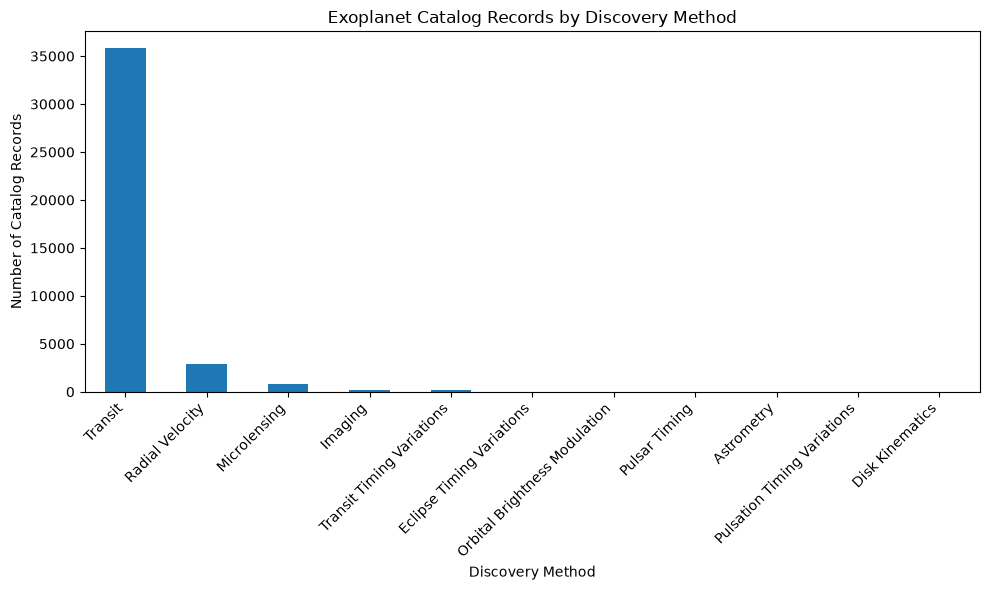

In [15]:
plt.figure(figsize=(10, 6))

discovery_counts.plot(kind="bar")

plt.title("Exoplanet Catalog Records by Discovery Method")
plt.xlabel("Discovery Method")
plt.ylabel("Number of Catalog Records")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Interpretation

The majority of confirmed exoplanets in this dataset were discovered using the Transit method, followed by the Radial Velocity method.

This is an important characteristic of the dataset because each detection technique measures different physical quantities.

For example:

- Transit observations directly measure how much starlight is blocked, making planet radius relatively easy to estimate.
- Radial velocity observations measure the motion of the host star, allowing estimates of planetary mass rather than radius.
- Imaging and microlensing detect planets through completely different physical mechanisms and therefore contribute different types of measurements.

As a result, missing values in this dataset are expected and are largely driven by observational limitations rather than data quality problems.

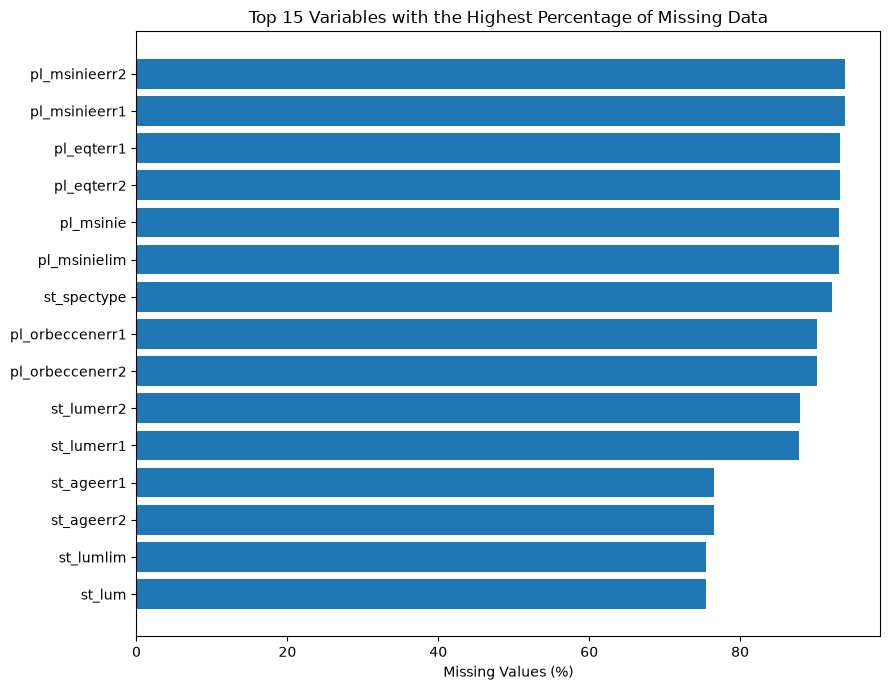

In [16]:
missing_plot = (
    missing[missing["Missing (%)"] > 0]
    .head(15)
    .sort_values("Missing (%)")
)

plt.figure(figsize=(9, 7))

plt.barh(
    missing_plot.index,
    missing_plot["Missing (%)"]
)

plt.xlabel("Missing Values (%)")
plt.title("Top 15 Variables with the Highest Percentage of Missing Data")

plt.tight_layout()
plt.show()

## Interpretation

Several planetary and stellar variables contain a substantial proportion of missing observations.

Rather than indicating poor data quality, these missing values primarily reflect the limitations of astronomical observations. Certain properties can only be measured when specific observational conditions are met or when a planet has been detected using a particular method.

This means that missing values are unlikely to be completely random, an important consideration for both preprocessing and model interpretation later in the project.

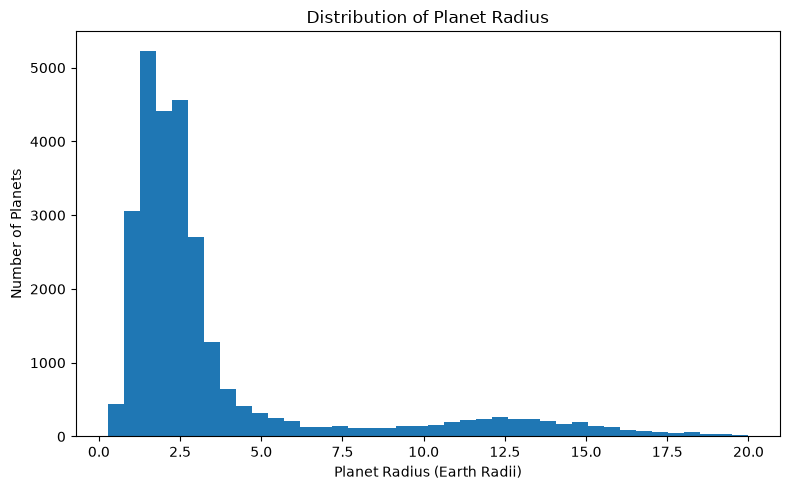

In [17]:
radius_vis = df[
    (df["pl_rade"].notna()) &
    (df["pl_rade"] > 0) &
    (df["pl_rade"] <= 20)
]

plt.figure(figsize=(8,5))

plt.hist(
    radius_vis["pl_rade"],
    bins=40
)

plt.title("Distribution of Planet Radius")
plt.xlabel("Planet Radius (Earth Radii)")
plt.ylabel("Number of Planets")

plt.tight_layout()
plt.show()

## Interpretation

Most confirmed exoplanets in the dataset have radii below approximately 4 Earth radii, while progressively fewer large planets are observed.

A small number of extremely large planets create a strongly right-skewed distribution. These outliers have been excluded from this visualization only to improve readability; they remain part of the dataset for later analysis.

The observed distribution reflects both astrophysical processes and observational bias, since larger planets are generally easier to detect than smaller ones.

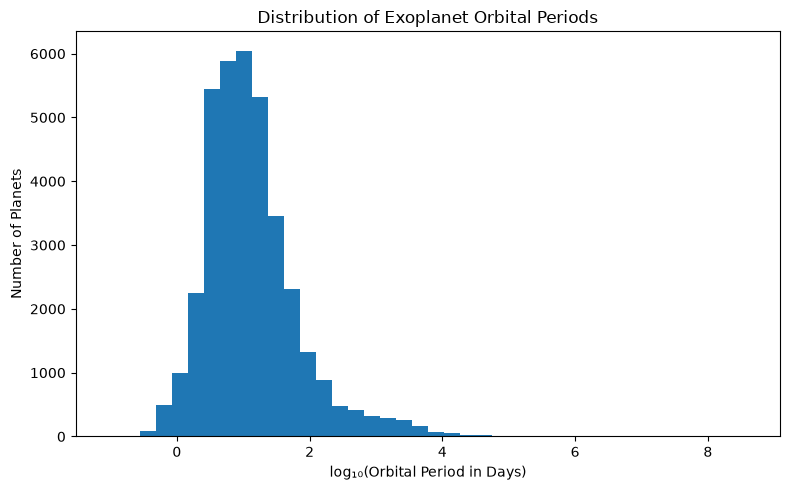

In [18]:
import numpy as np

orbital_period = df[
    df["pl_orbper"].notna() &
    (df["pl_orbper"] > 0)
]["pl_orbper"]

plt.figure(figsize=(8,5))

plt.hist(
    np.log10(orbital_period),
    bins=40
)

plt.title("Distribution of Exoplanet Orbital Periods")
plt.xlabel("log₁₀(Orbital Period in Days)")
plt.ylabel("Number of Planets")

plt.tight_layout()
plt.show()

## Interpretation

Exoplanet orbital periods span many orders of magnitude, ranging from less than one day to several million days. Plotting the logarithm of the orbital period provides a clearer view of the overall distribution by reducing the influence of extreme values.

Most confirmed exoplanets in the dataset have relatively short orbital periods. This pattern is influenced by observational selection effects, as planets with shorter periods transit their host stars more frequently and therefore have a higher probability of being detected by transit surveys.

The broad range of orbital periods also highlights the diversity of planetary systems represented in the NASA Exoplanet Archive.

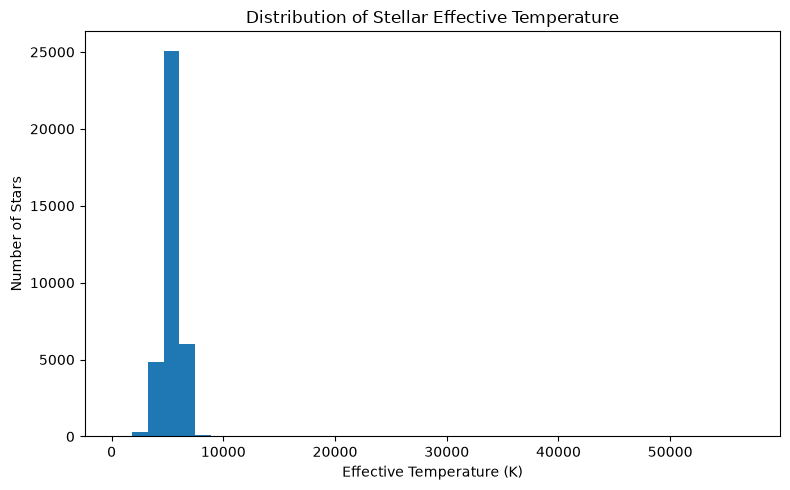

In [19]:
stellar_temp = df[df["st_teff"].notna()]

plt.figure(figsize=(8,5))

plt.hist(
    stellar_temp["st_teff"],
    bins=40
)

plt.title("Distribution of Stellar Effective Temperature")
plt.xlabel("Effective Temperature (K)")
plt.ylabel("Number of Stars")

plt.tight_layout()
plt.show()

## Interpretation

Most host stars have effective temperatures similar to F-, G-, and K-type stars, with comparatively fewer very cool or very hot stars represented.

This reflects both the stellar population observed by exoplanet surveys and the greater observational challenges associated with detecting planets around certain types of stars.

### Research Question

Are there observable relationships between key planetary and stellar properties that may influence later machine learning modeling?

### Correlation Method

Pearson correlation coefficients are calculated using pairwise available
observations. Because the selected variables have different patterns of missing
data, each feature pair may be calculated using a different number of observations.

Therefore, these correlations are exploratory and should not be interpreted as
causal relationships.

A weak Pearson correlation indicates only a weak linear relationship. It does not
rule out nonlinear relationships that may still be useful for machine learning.

In [20]:
selected_features = {
    "pl_rade": "Planet Radius",
    "pl_orbper": "Orbital Period",
    "pl_eqt": "Equilibrium Temp",
    "st_teff": "Stellar Temp",
    "st_rad": "Stellar Radius",
    "st_met": "Metallicity",
    "st_age": "Stellar Age",
    "sy_dist": "Distance"
}


In [21]:
correlation_features = list(selected_features.keys())

pairwise_counts = df[correlation_features].notna().astype(int).T.dot(
    df[correlation_features].notna().astype(int)
)

pairwise_counts
correlation = df[correlation_features].corr()

### Pairwise Sample Sizes

Because missing values are handled pairwise during correlation analysis, different feature pairs may be based on different numbers of available observations.

The table below shows the number of observations contributing to each pairwise correlation. This is important when interpreting correlations involving variables with substantial missingness.

In [22]:
plt.figure(figsize=(9, 7))

plt.imshow(
    spearman_correlation,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

plt.colorbar(label="Spearman Correlation Coefficient")

plt.xticks(
    range(len(labels)),
    labels,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(labels)),
    labels
)

for i in range(len(spearman_correlation)):
    for j in range(len(spearman_correlation)):
        plt.text(
            j,
            i,
            f"{spearman_correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title(
    "Spearman Correlation Between Selected Planetary and Stellar Properties"
)

plt.tight_layout()
plt.show()

NameError: name 'spearman_correlation' is not defined

<Figure size 900x700 with 0 Axes>

In [ ]:
correlation.round(3)

,pl_rade,pl_orbper,pl_eqt,st_teff,st_rad,st_met,st_age,sy_dist
pl_rade,1.000,0.001,0.012,0.010,0.010,-0.006,0.000,0.003
pl_orbper,0.001,1.000,-0.007,-0.012,-0.002,0.001,-0.013,-0.007
pl_eqt,0.012,-0.007,1.000,0.391,0.416,0.197,-0.157,-0.013
st_teff,0.010,-0.012,0.391,1.000,0.047,0.044,-0.245,0.308
st_rad,0.010,-0.002,0.416,0.047,1.000,-0.003,-0.036,0.009
st_met,-0.006,0.001,0.197,0.044,-0.003,1.000,-0.180,-0.094
st_age,0.000,-0.013,-0.157,-0.245,-0.036,-0.180,1.000,-0.122
sy_dist,0.003,-0.007,-0.013,0.308,0.009,-0.094,-0.122,1.000


In [ ]:
correlation_pairs = []

for i in range(len(correlation.columns)):
    for j in range(i + 1, len(correlation.columns)):
        correlation_pairs.append({
            "Feature 1": correlation.columns[i],
            "Feature 2": correlation.columns[j],
            "Pearson Correlation": correlation.iloc[i, j]
        })

correlation_pairs = pd.DataFrame(correlation_pairs)

correlation_pairs = (
    correlation_pairs
    .sort_values(
        "Pearson Correlation",
        key=lambda x: x.abs(),
        ascending=False
    )
    .reset_index(drop=True)
)

correlation_pairs.round(3)

,Feature 1,Feature 2,Pearson Correlation
0,pl_eqt,st_rad,0.416
1,pl_eqt,st_teff,0.391
2,st_teff,sy_dist,0.308
3,st_teff,st_age,-0.245
4,pl_eqt,st_met,0.197
5,st_met,st_age,-0.180
6,pl_eqt,st_age,-0.157
7,st_age,sy_dist,-0.122
8,st_met,sy_dist,-0.094
9,st_teff,st_rad,0.047


### Spearman Correlation

Pearson correlation measures linear relationships between variables. Spearman correlation instead evaluates whether variables have a monotonic relationship, meaning that one variable generally increases or decreases as the other changes, even if the relationship is not linear.

Comparing Pearson and Spearman correlations can therefore reveal relationships that may be monotonic but nonlinear.

In [ ]:
spearman_correlation = df[correlation_features].corr(
    method="spearman"
)

spearman_correlation.round(3)

,pl_rade,pl_orbper,pl_eqt,st_teff,st_rad,st_met,st_age,sy_dist
pl_rade,1.000,0.166,0.016,0.163,0.298,0.253,-0.053,0.037
pl_orbper,0.166,1.000,-0.785,0.074,0.111,-0.086,0.009,0.065
pl_eqt,0.016,-0.785,1.000,0.371,0.482,0.207,-0.110,0.043
st_teff,0.163,0.074,0.371,1.000,0.757,-0.022,-0.313,0.428
st_rad,0.298,0.111,0.482,0.757,1.000,0.254,-0.049,0.300
st_met,0.253,-0.086,0.207,-0.022,0.254,1.000,-0.161,-0.115
st_age,-0.053,0.009,-0.110,-0.313,-0.049,-0.161,1.000,-0.097
sy_dist,0.037,0.065,0.043,0.428,0.300,-0.115,-0.097,1.000


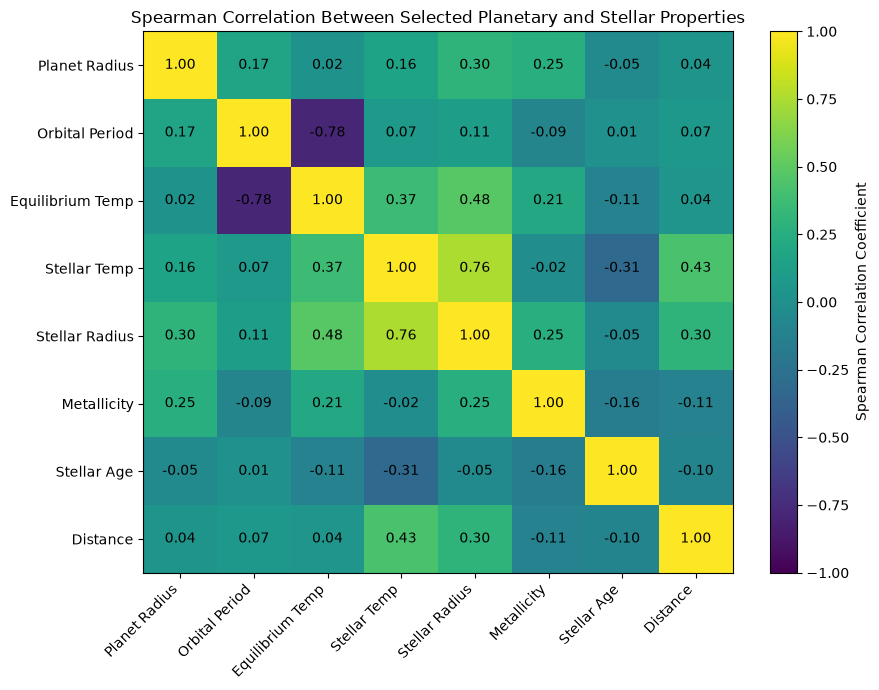

In [ ]:
plt.figure(figsize=(9, 7))

plt.imshow(
    spearman_correlation,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

plt.colorbar(label="Spearman Correlation Coefficient")

plt.xticks(
    range(len(labels)),
    labels,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(labels)),
    labels
)

for i in range(len(spearman_correlation)):
    for j in range(len(spearman_correlation)):
        plt.text(
            j,
            i,
            f"{spearman_correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title(
    "Spearman Correlation Between Selected Planetary and Stellar Properties"
)

plt.tight_layout()
plt.show()

In [ ]:
spearman_pairs = []

for i in range(len(spearman_correlation.columns)):
    for j in range(i + 1, len(spearman_correlation.columns)):
        spearman_pairs.append({
            "Feature 1": spearman_correlation.columns[i],
            "Feature 2": spearman_correlation.columns[j],
            "Spearman": spearman_correlation.iloc[i, j]
        })

spearman_pairs = pd.DataFrame(spearman_pairs)

correlation_comparison = correlation_pairs.merge(
    spearman_pairs,
    on=["Feature 1", "Feature 2"]
)

correlation_comparison["Difference"] = (
    correlation_comparison["Spearman"] -
    correlation_comparison["Pearson Correlation"]
).abs()

correlation_comparison.round(3)

,Feature 1,Feature 2,Pearson Correlation,Spearman,Difference
0,pl_eqt,st_rad,0.416,0.482,0.066
1,pl_eqt,st_teff,0.391,0.371,0.019
2,st_teff,sy_dist,0.308,0.428,0.120
3,st_teff,st_age,-0.245,-0.313,0.067
4,pl_eqt,st_met,0.197,0.207,0.010
5,st_met,st_age,-0.180,-0.161,0.019
6,pl_eqt,st_age,-0.157,-0.110,0.048
7,st_age,sy_dist,-0.122,-0.097,0.025
8,st_met,sy_dist,-0.094,-0.115,0.020
9,st_teff,st_rad,0.047,0.757,0.710


### Interpretation

Correlation measures only linear association and therefore cannot detect nonlinear relationships or interactions between variables.

A few moderate relationships are visible. For example, stellar radius and stellar effective temperature show some association, which is expected because both describe fundamental properties of the host star.

The generally modest pairwise correlations suggest that the candidate variables do not exhibit strong linear relationships with one another. However, pairwise correlation alone cannot determine whether a feature will be useful for classification, since machine learning models may identify nonlinear or multivariable relationships. Model-based feature importance and ablation experiments are therefore required to evaluate predictive contribution.

### Scientific Implication

The generally modest correlations among the candidate stellar features indicate that these variables provide substantially different information about their host stars rather than being simple duplicates of one another.

This does not, by itself, establish whether any individual feature is predictive of gas giant classification. A feature may have a strong nonlinear or otherwise useful relationship with the target even if its pairwise correlation with other features is weak.

The predictive contribution of each stellar property will therefore be evaluated using model benchmarking, feature ablation, permutation importance, and SHAP analysis in later notebooks.

In [ ]:
missing_by_method = (
    df.groupby("discoverymethod")[
        ["pl_rade", "pl_msinie", "st_teff", "st_rad", "st_met"]
    ]
    .apply(lambda group: group.isna().mean() * 100)
)

missing_by_method.round(2)

,pl_rade,pl_msinie,st_teff,st_rad,st_met
discoverymethod,,,,,
Astrometry,100.00,83.33,33.33,33.33,33.33
Disk Kinematics,100.00,100.00,0.00,0.00,100.00
Eclipse Timing Variations,100.00,46.15,61.54,65.38,100.00
Imaging,72.19,99.47,49.73,72.73,85.56
Microlensing,100.00,100.00,96.76,100.00,99.25
Orbital Brightness Modulation,38.10,80.95,0.00,14.29,38.10
Pulsar Timing,100.00,46.15,92.31,100.00,100.00
Pulsation Timing Variations,100.00,0.00,0.00,50.00,50.00
Radial Velocity,95.51,15.08,23.04,38.43,29.75


In [ ]:
research_variables = [
    "st_teff",
    "st_rad",
    "st_met",
    "pl_rade"
]

outlier_summary = []

for column in research_variables:
    series = df[column].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    outlier_summary.append({
        "Variable": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Potential Outliers": len(outliers),
        "Outlier (%)": len(outliers) / len(series) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.round(3)

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers,Outlier (%)
0,st_teff,5090.000,5949.000,859.000,3801.500,7237.500,1991,5.477
1,st_rad,0.785,1.212,0.427,0.145,1.852,1834,5.019
2,st_met,-0.149,0.120,0.269,-0.552,0.523,443,1.770
3,pl_rade,1.560,3.300,1.740,-1.050,5.910,4159,15.102


## Dataset Strengths

This dataset provides several advantages for investigating relationships between stellar properties and gas giant occurrence:

- Large sample size: The dataset contains thousands of catalog records, providing substantial data for exploratory analysis and machine learning, although repeated planet identifiers must be addressed before modeling.
- **Real observational data:** The dataset originates from the NASA Exoplanet Archive, making the project representative of real astronomical research rather than synthetic examples.
- **Rich feature set:** Measurements describing planetary characteristics, stellar properties, and planetary systems enable both astrophysical interpretation and predictive modeling.
- **Multiple discovery techniques:** Combining observations from several detection methods increases the diversity of planetary systems represented in the dataset.

## Availability of Variables Used in the Research Question

The final research question depends on four key variables:

- `st_teff`: host-star effective temperature
- `st_rad`: host-star radius
- `st_met`: host-star metallicity
- `pl_rade`: planetary radius, used to define the target class

The availability of these variables is therefore particularly important because observations lacking one or more of them may be excluded from the modeling dataset.

## Dataset Limitations

Several limitations should be considered when interpreting analyses based on this dataset:

- **Observational selection effects:** Larger planets and planets with shorter orbital periods are generally easier to detect, meaning the observed sample is not fully representative of all planetary systems.
- **Missing values are not random:** Many measurements are unavailable because different discovery techniques measure different physical quantities. As a result, missing data reflect observational constraints rather than random omissions.
- **Repeated observations:** Multiple rows exist for some confirmed planets. These may reflect multiple catalog records, updated measurements, or multiple associated observations. The implications of these repeated records are examined during preprocessing.
- **Measurement uncertainty:** Astronomical observations contain uncertainties that vary depending on the detection method, instrument sensitivity, and observing conditions.

These limitations are characteristic of real astronomical survey data and should be considered throughout subsequent preprocessing and model interpretation.

In [ ]:
research_variables = ["st_teff", "st_rad", "st_met", "pl_rade"]

research_variable_availability = pd.DataFrame({
    "Variable": research_variables,
    "Available Records": [
        df[column].notna().sum()
        for column in research_variables
    ],
    "Missing Records": [
        df[column].isna().sum()
        for column in research_variables
    ],
    "Missing (%)": [
        df[column].isna().mean() * 100
        for column in research_variables
    ]
})

research_variable_availability.round(2)

,Variable,Available Records,Missing Records,Missing (%)
0,st_teff,36351,3603,9.02
1,st_rad,36542,3412,8.54
2,st_met,25026,14928,37.36
3,pl_rade,27540,12414,31.07


## Observational Selection Effects

The dataset represents confirmed exoplanets that have been successfully detected and
characterized, rather than a random sample of all planets that exist.

Detection probability depends on factors such as:

- planet size,
- orbital period,
- host-star properties,
- observational method,
- instrument sensitivity,
- and observing duration.

Therefore, any machine learning model trained on this dataset learns patterns within
the observed population of confirmed exoplanets. Its predictions should not be
interpreted as directly representing the occurrence rate of gas giants throughout
the galaxy.

In [ ]:
research_variables = [
    "st_teff",
    "st_rad",
    "st_met",
    "pl_rade"
]

complete_cases = df[research_variables].notna().all(axis=1)

print(
    f"Records with all research variables available: "
    f"{complete_cases.sum():,}"
)

print(
    f"Percentage of raw records retained before target filtering: "
    f"{complete_cases.mean() * 100:.2f}%"
)

Records with all research variables available: 18,735
Percentage of raw records retained before target filtering: 46.89%


## Key Scientific Findings

Analysis of the raw NASA Exoplanet Archive reveals several important characteristics:

- The **Transit** method is the dominant discovery technique represented in the dataset.
- Planet radii are strongly right-skewed, with most confirmed exoplanets having relatively small radii and a small number of extreme outliers.
- Orbital periods span several orders of magnitude, illustrating the remarkable diversity of planetary systems.
- The catalog is concentrated around effective temperatures commonly associated with F-, G-, and K-type host stars, although a broader range of stellar temperatures is also represented.
- Missing values primarily arise from observational limitations rather than data quality issues.
- Correlations among stellar and planetary variables are generally modest, suggesting that multiple stellar properties may collectively contribute to predicting gas giant occurrence.

## Transition to Data Preprocessing

The raw dataset contains substantial missingness, repeated planet identifiers,
highly skewed physical variables, and observations collected through multiple
detection methods.

These characteristics determine the preprocessing decisions in the next notebook.

The next stage will:

1. Select scientifically justified variables.
2. Define the gas-giant classification target.
3. Resolve repeated planet identifiers.
4. Separate target construction from model predictors.
5. Split the data into training and testing subsets.
6. Learn imputation statistics using only the training data.
7. Export the resulting datasets for model development.

No machine learning model is trained in this notebook.